**Name:** Sneha Mahendra Kamble

**PRN:** 124B2B030

**Title:** You are a data scientist at a real estate company tasked with building a model to predict house prices based
on features like area, number of bedrooms, location, and age of the house.



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
# import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
# from statsmodels.sandbox.stats.runs import runstest_1samp
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, r2_score, mean_absolute_error, mean_squared_error



In [ ]:
df=pd.read_csv("/content/Housing.csv")
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [ ]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [ ]:
df.isnull().sum()
df.duplicated().sum()
df.shape

(545, 13)

In [ ]:
numeric_cols = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']

Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = (df[numeric_cols] < lower_bound) | (df[numeric_cols] > upper_bound)

for col in numeric_cols:
    num_outliers = outliers[col].sum()
    print(f"{col} has {num_outliers} outliers")

df = df[~outliers.any(axis=1)]
print(f"Number of rows after removing outliers: {len(df)}")



price has 15 outliers
area has 12 outliers
bedrooms has 12 outliers
bathrooms has 1 outliers
stories has 41 outliers
parking has 12 outliers
Number of rows after removing outliers: 463


In [ ]:
# df = df.copy()

# df['area_sqrt'] = np.sqrt(df['area'].astype(float))
# df['price_log'] = np.log(df['price'].astype(float))


Square root is a mild transformation, useful for moderately skewed data.<br>
Log is a stronger transformation, best for highly skewed data with large ranges.

In [ ]:
binary_cols = ["mainroad", "guestroom", "basement","hotwaterheating", "airconditioning", "prefarea"]

df = df.drop(columns=binary_cols)
df.head()

,price,area,bedrooms,bathrooms,stories,parking,furnishingstatus
15,9100000,6000,4,1,2,2,semi-furnished
16,9100000,6600,4,2,2,1,unfurnished
18,8890000,4600,3,2,2,2,furnished
19,8855000,6420,3,2,2,1,semi-furnished
20,8750000,4320,3,1,2,2,semi-furnished


In [ ]:
df = pd.get_dummies(df, columns=["furnishingstatus"], drop_first=True)
df.head()

,price,area,bedrooms,bathrooms,stories,parking,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
15,9100000,6000,4,1,2,2,True,False
16,9100000,6600,4,2,2,1,False,True
18,8890000,4600,3,2,2,2,False,False
19,8855000,6420,3,2,2,1,True,False
20,8750000,4320,3,1,2,2,True,False


In [ ]:
df.describe()


,price,area,bedrooms,bathrooms,stories,parking
count,4.630000e+02,463.000000,463.000000,463.000000,463.000000,463.000000
mean,4.373745e+06,4766.583153,2.857451,1.220302,1.615551,0.587473
std,1.465136e+06,1795.315000,0.658924,0.440211,0.626901,0.776003
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.342500e+06,3490.000000,2.000000,1.000000,1.000000,0.000000
50%,4.200000e+06,4300.000000,3.000000,1.000000,2.000000,0.000000
75%,5.222000e+06,6000.000000,3.000000,1.000000,2.000000,1.000000
max,9.100000e+06,10500.000000,4.000000,3.000000,3.000000,2.000000


In [ ]:
X = df.drop("price", axis=1)   # independent vars
y = df["price"]                # dependent var

Linear Regression is a statistical method used to model and analyze the relationship between a dependent variable (target) and one or more independent variables (predictors/features) by fitting a linear equation to observed data.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

**Adjusted R²** : Similar to R², but adjusts for the number of predictors in the model.<br>
 **R² Score** : Measures how well the independent variables explain the variability of the dependent variable.<br>
**Mean Absolute Error (MAE):** The average of the absolute differences between the predicted values and the actual values.<br>
**Mean Squared Error (MSE):** The average of the squared differences between predicted and actual values.<br>
**Root Mean Squared Error (RMSE)** :  The square root of MSE. It brings the error back to the same scale as the target variable.

In [ ]:
# Accuracy
r2 = r2_score(y_test, y_pred)
n = X_test.shape[0]
p = X_test.shape[1]

# Adjusted R²
adj_r2 = 1 - (1 - r2) * ((n - 1) / (n - p - 1))

# Error metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("\nModel Performance Metrics")
print(f"R² Score: {r2:.4f}")
print(f"Adjusted R²: {adj_r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

print("\nCoefficients:", model.coef_)
print("Intercept:", model.intercept_)



Model Performance Metrics
R² Score: 0.5254
Adjusted R²: 0.4863
Mean Absolute Error (MAE): 865669.64
Mean Squared Error (MSE): 1235729601785.05
Root Mean Squared Error (RMSE): 1111633.75

Coefficients: [ 3.22601781e+02  1.01759755e+05  9.11995103e+05  3.96773022e+05
  3.03473975e+05 -1.66830369e+05 -6.37170471e+05]
Intercept: 902990.3315955475


The model accounts for about 71% of the changes in house prices (R² = 0.71).<br>
On average, the predictions are off by about 0.67 million (MAE), with typical errors reaching 0.87 million (RMSE).

**Key factors that influence prices:** <br>
**Increase price:** Larger area, air conditioning, basement, guestroom, semi-furnished or fully furnished homes.

**Decrease price:** Unfurnished homes.


**Linearity Check:** The relationship between the independent variables and the dependent variable is linear.

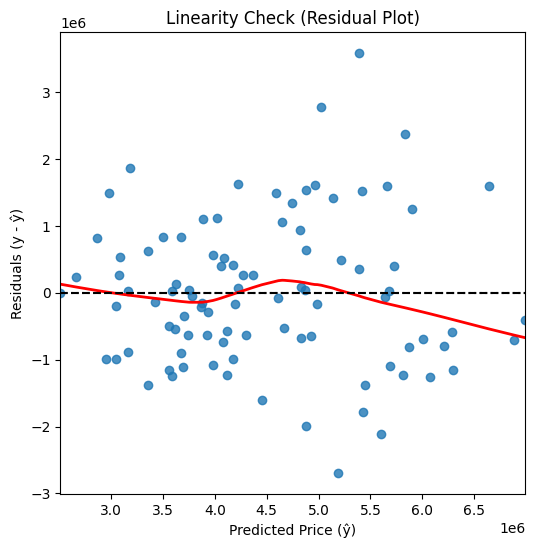

In [ ]:
# Linearity check
residuals = y_test - y_pred

plt.figure(figsize=(6,6))
sns.residplot(x=y_pred, y=residuals,lowess=True,line_kws={"color":"red", "lw":2})
plt.xlabel("Predicted Price (ŷ)")
plt.ylabel("Residuals (y - ŷ)")
plt.title("Linearity Check (Residual Plot)")
plt.axhline(0, color="black", linestyle="--")
plt.show()


The residuals are randomly scattered around zero, which supports the linearity assumption of the regression model.<br>
A slight curve in the red trend line indicates minor non-linearity, but it is not very strong.<br>
The spread of residuals increases at higher predicted values, suggesting mild heteroscedasticity.<br>
No major outliers or strong patterns are observed, so overall the model fit is reasonably good.

**Independence of Errors:** The residuals (errors) are independent of each other.

In [ ]:
# Independence of Errors (Durbin-Watson Test)
dw = durbin_watson(residuals)
print(f"Durbin-Watson: {dw:.3f}")


Durbin-Watson: 2.444


The **Durbin-Watson (DW)** test checks for autocorrelation, which is the correlation of residuals over time, in regression residuals.

DW ≈ 2 → no autocorrelation (good).<br>
DW < 2 → positive autocorrelation.<br>
DW > 2 → negative autocorrelation.<br>

Since the value is greater than 2, it indicates a slight negative autocorrelation in the residuals.<br>
The residuals do not show serious positive correlation, which is good for the validity of the regression model.<br>
Overall, the model residuals are fairly independent.

**Homoscedasticity**: The residuals have constant variance across all levels of the independent variables.

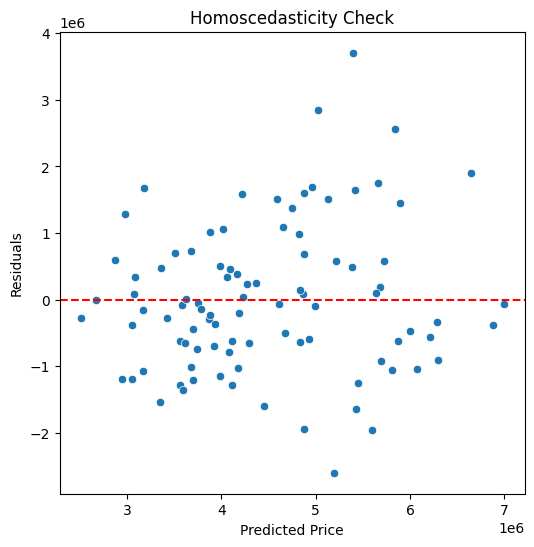

In [ ]:
# Homoscedasticity
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Homoscedasticity Check")
plt.show()


The residuals are randomly scattered around zero without a clear pattern, suggesting that the assumption of homoscedasticity is mostly satisfied. There are a few outliers visible, and the spread of residuals is slightly wider at higher predicted prices. Overall, variance appears fairly constant, indicating the model is reasonably valid.

 **Normality of Residuals:** The residuals (errors) are normally distributed.

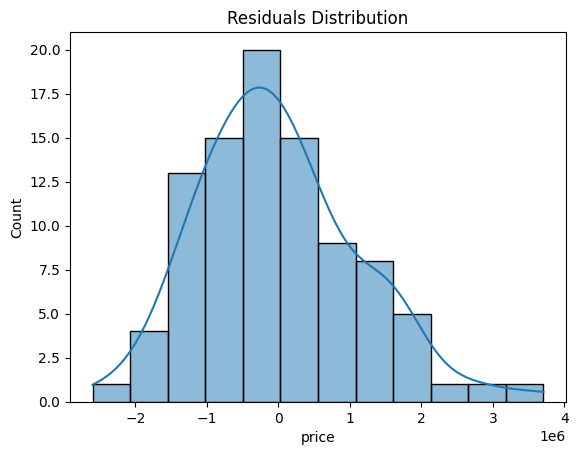

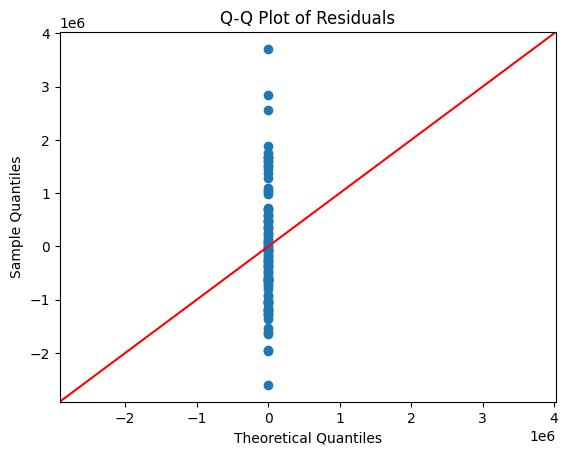

In [ ]:
# Normality of Residuals

# Histogram
sns.histplot(residuals, kde=True)
plt.title("Residuals Distribution")
plt.show()

# Q-Q plot
sm.qqplot(residuals, line='45')
plt.title("Q-Q Plot of Residuals")
plt.show()


The residuals distribution is roughly bell-shaped and centered around zero, suggesting approximate normality. Most residuals fall close to zero, with fewer values in the tails. There are some slight deviations and longer tails, indicating mild skewness or outliers. Overall, the normality assumption is reasonably satisfied.

The Q-Q plot shows that the residuals deviate strongly from the diagonal reference line, especially across the distribution. Instead of following a straight line, the points are tightly clustered around zero on the x-axis, indicating non-normality.

**No mulitcollinearity**: Independent variables are not highly correlated with each other.

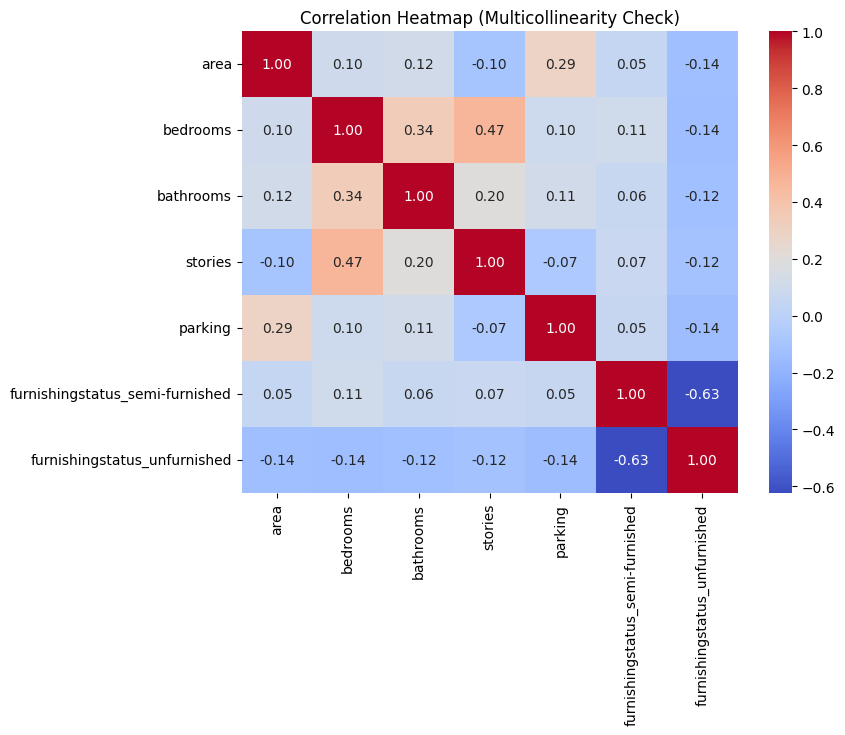

In [ ]:
plt.figure(figsize=(8,6))
corr_matrix = X.corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Multicollinearity Check)")
plt.show()


he correlation values among most independent variables are low, indicating that multicollinearity is minimal in the dataset.<br>
A moderate correlation is observed between bedrooms and stories (0.47), and between bedrooms and bathrooms (0.34), which is reasonable in housing data.<br>
The strongest negative relationship is between semi-furnished and unfurnished status (-0.63), which is expected as they are mutually exclusive categories.

In [ ]:

X_num = X.select_dtypes(include=[np.number])
X_with_const = sm.add_constant(X_num)

vif = pd.DataFrame()
vif["Feature"] = X_num.columns
vif["VIF"] = [variance_inflation_factor(X_with_const.values, i+1)
              for i in range(len(X_num.columns))]

print(vif)

     Feature       VIF
0       area  1.128595
1   bedrooms  1.432341
2  bathrooms  1.149362
3    stories  1.335768
4    parking  1.114219


All VIF values are close to 1 and well below the common threshold of 5, indicating that multicollinearity is not present in the dataset.

VIF = 1 → no correlation with other predictors.<br>
1 < VIF < 5 → moderate correlation, usually acceptable.<br>
VIF ≥ 5 → potentially problematic (many use 5 as a cutoff).

Logistic Regression is a statistical and machine learning technique used for classification problems. Unlike linear regression, which predicts continuous values, logistic regression predicts the probability of a categorical outcome (e.g., yes/no, 0/1).

In [ ]:

df['expensive'] = (df['price'] > df['price'].median()).astype(int)

X = df.drop(['price', 'expensive'], axis=1)
y = df['expensive']

# Encode categorical columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [ ]:
# Train logistic regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

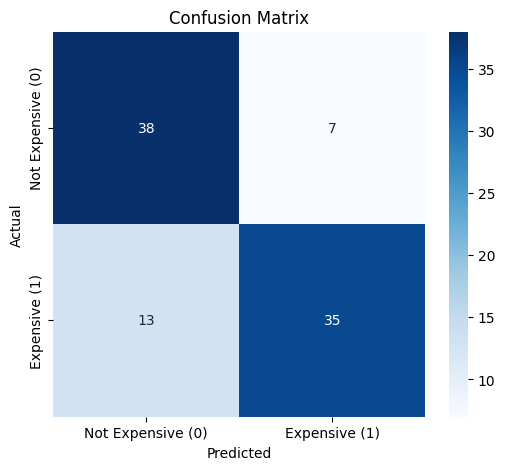

Accuracy: 0.7849462365591398
Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.84      0.79        45
           1       0.83      0.73      0.78        48

    accuracy                           0.78        93
   macro avg       0.79      0.79      0.78        93
weighted avg       0.79      0.78      0.78        93



In [ ]:

accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
labels = ['Not Expensive (0)', 'Expensive (1)']
report = classification_report(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

print("Accuracy:", accuracy)
print("Classification Report:\n", report)


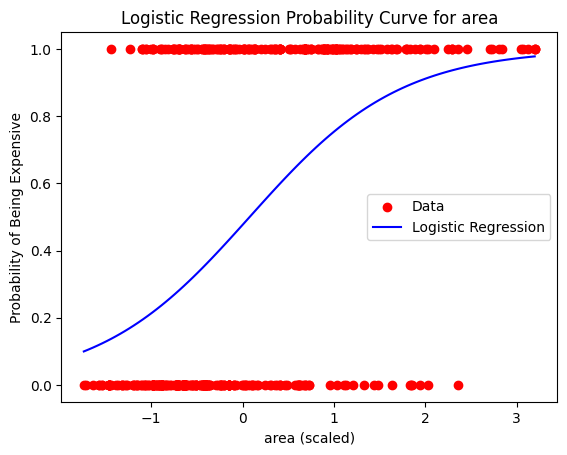

In [ ]:

feature_name = 'area'
X_feature = df[[feature_name]]
y_binary = df['expensive']


scaler_feature = StandardScaler()
X_feature_scaled = scaler_feature.fit_transform(X_feature)


model_single = LogisticRegression(max_iter=1000)
model_single.fit(X_feature_scaled, y_binary)

X_plot = np.linspace(X_feature_scaled.min(), X_feature_scaled.max(), 100).reshape(-1, 1)
y_prob = model_single.predict_proba(X_plot)[:, 1]


plt.scatter(X_feature_scaled, y_binary, color='red', label='Data')
plt.plot(X_plot, y_prob, color='blue', label='Logistic Regression')
plt.xlabel(f"{feature_name} (scaled)")
plt.ylabel("Probability of Being Expensive")
plt.title(f"Logistic Regression Probability Curve for {feature_name}")
plt.legend()
plt.show()


The logistic regression model shows the S-shaped (sigmoid) probability curve, mapping area (scaled) to the probability of a house being expensive.<br>
As the area increases, the probability of being expensive also increases, showing a positive relationship between area and price category.<br>
Most data points (red dots) are clustered near 0 and 1, indicating that houses are clearly classified as either cheap (0) or expensive (1).<br>